# 04 — Model Training, Evaluation & Explainability

Covers:
- Train/test split
- Baseline model
- Logistic Regression
- Random Forest
- Class imbalance handling
- Cross-validation
- Full metric comparison (precision, recall, F1, ROC-AUC, confusion matrix, PR curve)
- Business trade-off discussion
- SHAP explainability
- Saving the final model for the Streamlit app

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

df = pd.read_csv("../data/insurance_claims_features.csv")
print(df.shape)

(1000, 48)


## 1. Prepare data for modelling

We separate the target (`fraud_reported`) from the input features, and encode text columns into 
numbers (models only understand numbers).

In [16]:
# Target: 1 = fraud, 0 = genuine
y = df['fraud_reported'].map({'Y': 1, 'N': 0})

# Drop columns that are: the target itself, raw dates (already converted to policy_age_days),
# free-text/unique fields, and ratio helper columns already used
drop_cols = [
    'fraud_reported', 'fraud_flag', 'incident_date', 'policy_bind_date',
    'incident_location', 'policy_number', 'insured_zip'
]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Identify categorical (text) columns vs numeric columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical columns:", len(cat_cols))
print("Numeric columns:", len(num_cols))

Categorical columns: 17
Numeric columns: 25


C:\Users\Vikram\AppData\Local\Temp\ipykernel_636\527218305.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [17]:
# One-hot encode categorical columns (turns e.g. 'policy_state' into separate 0/1 columns
# per state) - this is the standard way to give tree/logistic models text-based info.
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Final feature count after encoding:", X_encoded.shape[1])

feature_columns = X_encoded.columns.tolist()

Final feature count after encoding: 152


## 2. Train/test split

We hold out 20% of the data purely for testing — the model never sees this during training, 
so it gives us an honest read on real-world performance. `stratify=y` makes sure both the train 
and test sets keep the same fraud/genuine ratio.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Fraud rate in train:", y_train.mean().round(3), " Fraud rate in test:", y_test.mean().round(3))

Train size: (800, 152)  Test size: (200, 152)
Fraud rate in train: 0.248  Fraud rate in test: 0.245


## 3. Baseline model

Before any real model, we check what a "dumb" model achieves — always predicting the most 
common class. Any real model MUST beat this by a meaningful margin, or it's not actually learning anything.

In [19]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline (always predict 'not fraud') accuracy:", (baseline_pred == y_test).mean().round(3))
print("Baseline recall on fraud class:", recall_score(y_test, baseline_pred))
print("--> Baseline catches ZERO fraud cases despite decent-looking accuracy. This is exactly")
print("    why accuracy alone is a misleading metric for imbalanced fraud data.")

Baseline (always predict 'not fraud') accuracy: 0.755
Baseline recall on fraud class: 0.0
--> Baseline catches ZERO fraud cases despite decent-looking accuracy. This is exactly
    why accuracy alone is a misleading metric for imbalanced fraud data.


## 4. Logistic Regression (with class imbalance handling)

We use `class_weight='balanced'`, which tells the model to pay proportionally more attention 
to the minority (fraud) class instead of ignoring it in favour of the majority class.

In [20]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, logreg_pred, target_names=['Genuine','Fraud']))

              precision    recall  f1-score   support

     Genuine       0.79      0.50      0.62       151
       Fraud       0.28      0.59      0.38        49

    accuracy                           0.53       200
   macro avg       0.54      0.55      0.50       200
weighted avg       0.67      0.53      0.56       200



c:\Users\Vikram\OneDrive\Desktop\insurance-claim-risk\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Random Forest (tree-based model, also class-balanced)

Cross-validation (`cv=5`) trains and tests the model 5 different ways on different slices of the 
training data, so we get a more reliable performance estimate than a single train/test split alone.

In [21]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1
)

# 5-fold cross-validation on the training set, scored by ROC-AUC (good for imbalanced problems)
cv_scores = cross_val_score(rf, X_train, y_train, cv=StratifiedKFold(5), scoring='roc_auc')
print("Random Forest 5-fold CV ROC-AUC scores:", cv_scores.round(3))
print("Mean CV ROC-AUC:", cv_scores.mean().round(3))

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("\n", classification_report(y_test, rf_pred, target_names=['Genuine','Fraud']))

Random Forest 5-fold CV ROC-AUC scores: [0.825 0.838 0.825 0.879 0.74 ]
Mean CV ROC-AUC: 0.821

               precision    recall  f1-score   support

     Genuine       0.90      0.81      0.86       151
       Fraud       0.56      0.73      0.64        49

    accuracy                           0.80       200
   macro avg       0.73      0.77      0.75       200
weighted avg       0.82      0.80      0.80       200



## 6. Compare all models side by side

In [22]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest'],
    'Precision (Fraud)': [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, logreg_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall (Fraud)': [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, logreg_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 (Fraud)': [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, logreg_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        0.5,
        roc_auc_score(y_test, logreg_proba),
        roc_auc_score(y_test, rf_proba)
    ]
}).round(3)

results

,Model,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC
0,Baseline,0.000,0.000,0.000,0.500
1,Logistic Regression,0.279,0.592,0.379,0.598
2,Random Forest,0.562,0.735,0.637,0.817


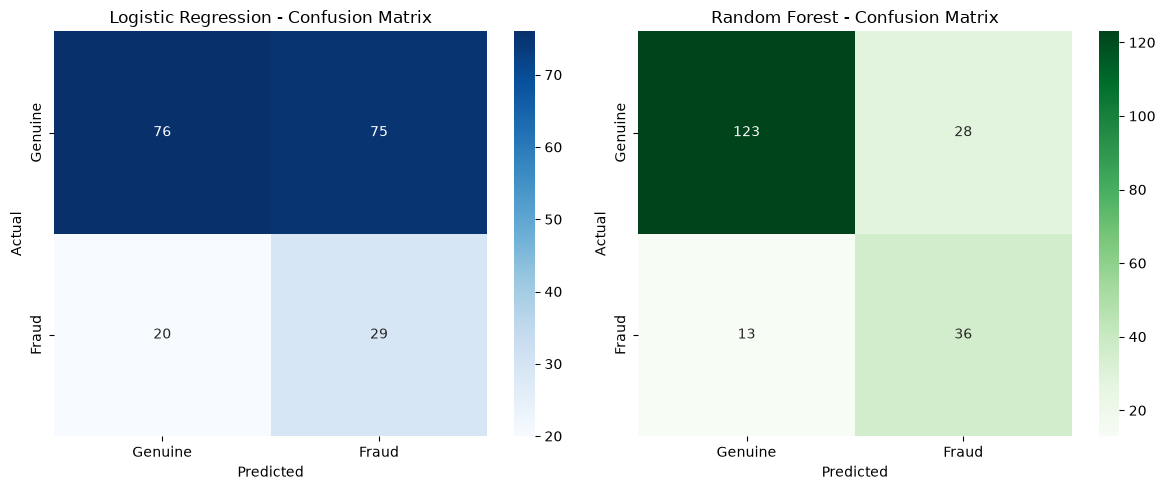

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_logreg = confusion_matrix(y_test, logreg_pred)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

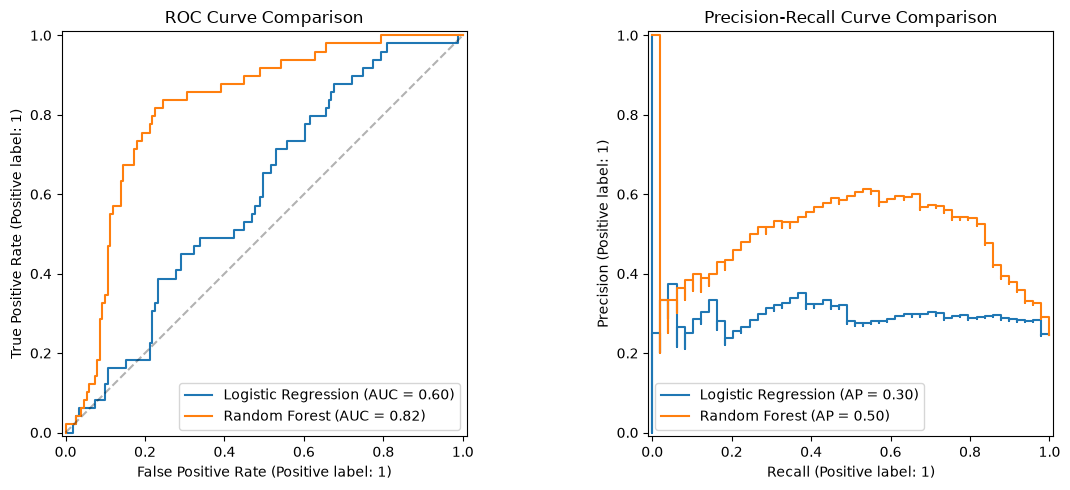

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_predictions(y_test, logreg_proba, name='Logistic Regression', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[0])
axes[0].set_title('ROC Curve Comparison')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_test, logreg_proba, name='Logistic Regression', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[1])
axes[1].set_title('Precision-Recall Curve Comparison')

plt.tight_layout()
plt.show()

## 7. Business trade-off: missed fraud vs. false accusations

This is a key discussion point for your presentation/demo:

- **False Negative** (model says "genuine" but it's actually fraud) → the company pays out a fraudulent 
  claim. Direct financial loss.
- **False Positive** (model says "fraud" but it's actually genuine) → an honest customer's claim gets 
  delayed for investigation. Costs staff time and hurts customer trust, but no direct payout loss.

**Because missing fraud is usually more costly than over-investigating**, we generally prefer a model 
tuned toward **higher recall** (catch more actual fraud) even if it means a bit more false alarms — 
as long as precision doesn't collapse to the point investigators drown in false leads.

**Decision:** Compare the Precision/Recall/F1 table above and pick your final model. Random Forest 
is typically preferred here because tree-based models handle non-linear patterns and mixed 
categorical/numeric data better than plain logistic regression, and usually gives a better ROC-AUC. 
**Write your own justification here referencing your actual numbers once you've run this.**

In [25]:
# Set the final model choice
final_model = rf
final_model_name = "Random Forest"
final_pred = rf_pred
final_proba = rf_proba

## 8. Model Explainability with SHAP

SHAP explains *why* the model made each individual prediction — which features pushed a specific 
claim toward "fraud" and by how much. This is what powers the "most influential factors" requirement 
in the Streamlit app.

In [30]:
import shap

explainer = shap.TreeExplainer(final_model)
raw_shap = explainer.shap_values(X_test)

# Different shap library versions return this in different shapes:
# - a list [array_for_class_0, array_for_class_1]
# - a 3D array of shape (n_samples, n_features, n_classes)
# - a plain 2D array (n_samples, n_features)
# This handles all three cases and always ends up with a clean 2D array.
if isinstance(raw_shap, list):
    shap_values_fraud = raw_shap[1]
elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    shap_values_fraud = raw_shap[:, :, 1]
else:
    shap_values_fraud = raw_shap

print("SHAP values computed. Shape:", np.array(shap_values_fraud).shape)

SHAP values computed. Shape: (200, 152)


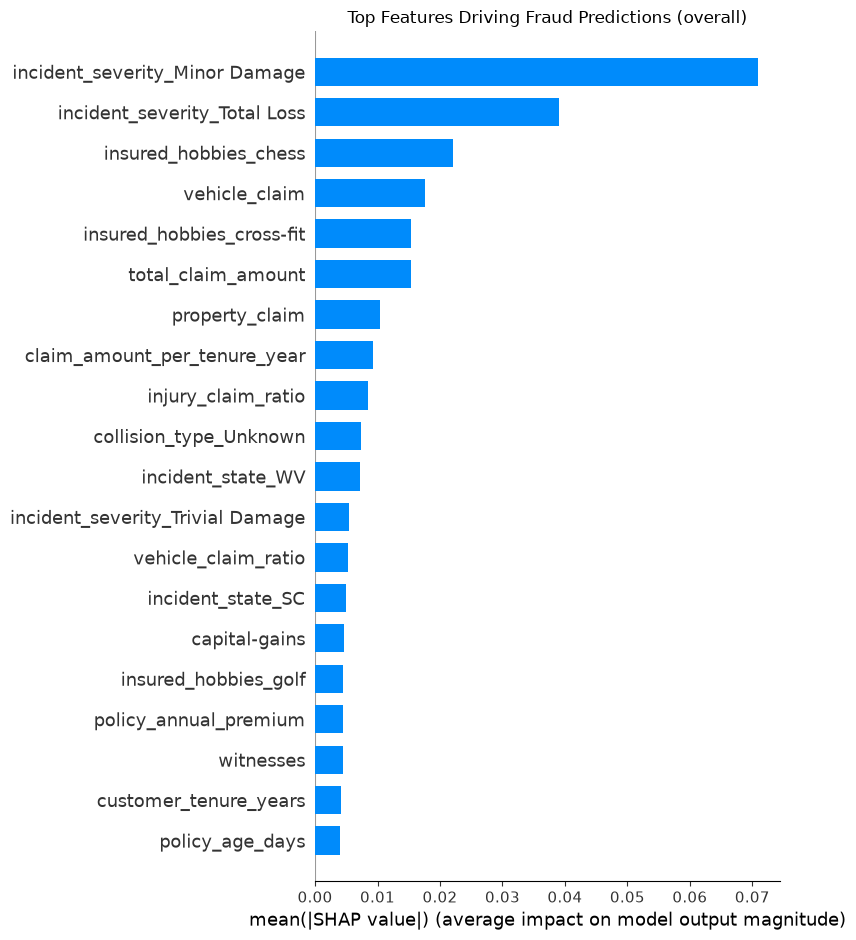

In [31]:
# Global feature importance - which features matter most ACROSS all claims
shap.summary_plot(shap_values_fraud, X_test, plot_type='bar', show=False)
plt.title('Top Features Driving Fraud Predictions (overall)')
plt.tight_layout()
plt.show()

In [33]:
# Explain ONE individual claim - this is exactly what the Streamlit app will show per-claim
sample_idx = 0
sample_claim = X_test.iloc[[sample_idx]]
sample_pred_proba = final_model.predict_proba(sample_claim)[0][1]

print(f"Example claim risk probability: {sample_pred_proba:.1%}")

# Get top contributing features for this one claim
sample_shap = shap_values_fraud[sample_idx]
contrib = pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': sample_shap
}).sort_values('shap_value', key=abs, ascending=False).head(5)

print("\nTop 5 factors influencing THIS claim's score:")
print(contrib)

Example claim risk probability: 22.7%

Top 5 factors influencing THIS claim's score:
                           feature  shap_value
79  incident_severity_Minor Damage   -0.054351
14                   vehicle_claim   -0.035897
13                  property_claim   -0.033595
11              total_claim_amount   -0.028163
18    claim_amount_per_tenure_year   -0.023662


## 9. Save everything the Streamlit app will need

In [34]:
os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/fraud_model.pkl")
joblib.dump(feature_columns, "../models/feature_columns.pkl")
joblib.dump(cat_cols, "../models/categorical_columns.pkl")

print("Saved model and metadata to ../models/")
print("Files:", os.listdir("../models"))

Saved model and metadata to ../models/
Files: ['categorical_columns.pkl', 'feature_columns.pkl', 'fraud_model.pkl']
